In [1]:
import sys

sys.path.insert(0, "../")
import matplotlib.pyplot as plt
from modules.functions_v3 import *
from modules.plot_utils import save_figure, apply_physics_paper_style

apply_physics_paper_style()

/opt/anaconda3/envs/gw/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


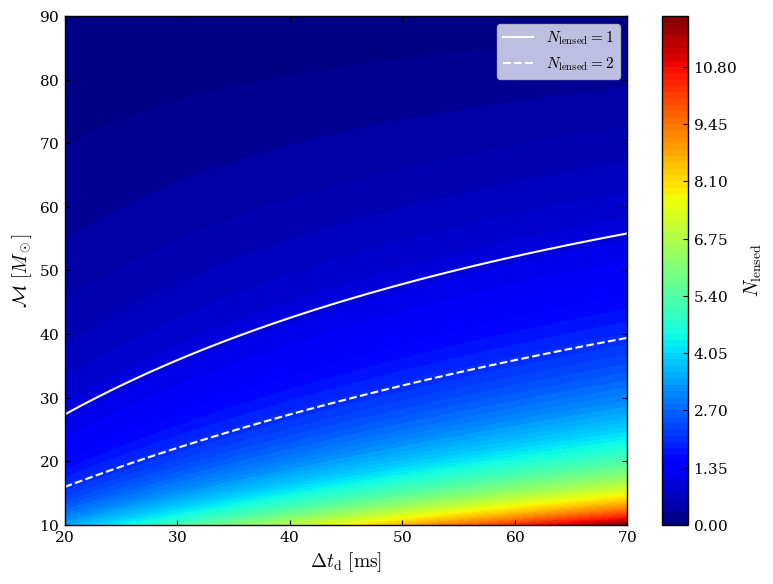

Saved figure: ../figures/n_lens_mcz_td.pdf


In [9]:
mcz_arr = np.linspace(10, 90, 81)  # [M_sun]
td_arr = np.linspace(0.02, 0.07, 51)  # [sec]
TD, MCZ = np.meshgrid(td_arr, mcz_arr)
Z = number_of_lens_cycles(MCZ, TD)  # [dimensionless]
mcz_1lens = mcz_for_n_lens_cycles(1.0, td_arr, f_min=20, eta=0.25)
mcz_2lens = mcz_for_n_lens_cycles(2.0, td_arr, f_min=20, eta=0.25)

fig = plt.figure(figsize=(8, 6))
cf = plt.contourf(TD * 1e3, MCZ, Z, levels=100, cmap="jet")
cbar = plt.colorbar(cf)
cbar.set_label(r"$N_{\mathrm{lensed}}$")
plt.xlabel(r"$\Delta t_{\mathrm{d}}\ [\mathrm{ms}]$")
plt.ylabel(r"$\mathcal{M}\ [M_\odot]$")

plt.plot(
    td_arr * 1e3, mcz_1lens, color="white", ls="-", label=r"$N_{\mathrm{lensed}}=1$"
)
plt.plot(
    td_arr * 1e3, mcz_2lens, color="white", ls="--", label=r"$N_{\mathrm{lensed}}=2$"
)

plt.legend(loc="upper right", framealpha=0.75)
plt.tight_layout()
plt.show()
save_figure(fig, "../figures/n_lens_mcz_td.pdf")

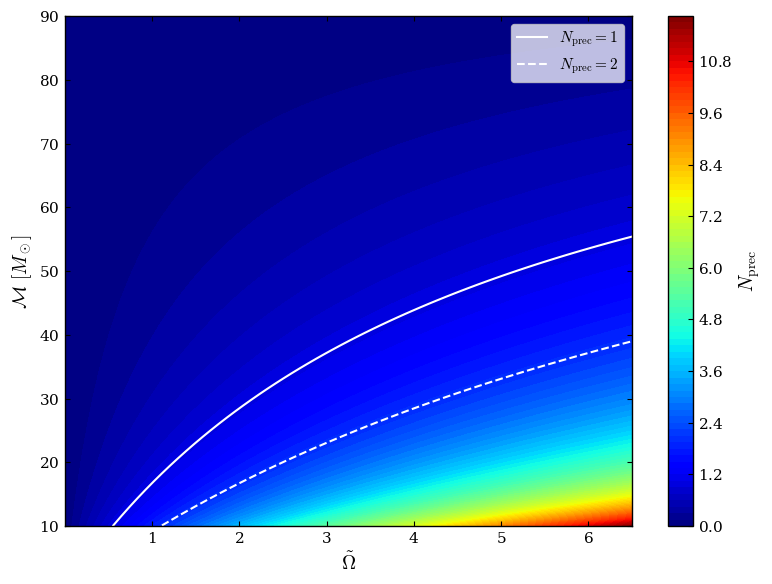

Saved figure: ../figures/n_prec_mcz_omega.pdf


In [10]:
mcz_arr = np.linspace(10, 90, 81)  # [M_sun]
omega_arr = np.linspace(0.001, 6.5, 71)  # [dimensionless]
OMEGA, MCZ = np.meshgrid(omega_arr, mcz_arr)
Z = number_of_prec_cycles(MCZ, OMEGA)  # [dimensionless]
mcz_1prec = mcz_for_n_prec_cycles(1.0, omega_arr, f_min=20, eta=0.25)
mcz_2prec = mcz_for_n_prec_cycles(2.0, omega_arr, f_min=20, eta=0.25)

# Cut off mcz_1prec and mcz_2prec at 10 Msun
mcz_1prec = np.where(mcz_1prec < 10, np.nan, mcz_1prec)
mcz_2prec = np.where(mcz_2prec < 10, np.nan, mcz_2prec)

fig = plt.figure(figsize=(8, 6))
cf = plt.contourf(OMEGA, MCZ, Z, levels=100, cmap="jet")
cbar = plt.colorbar(cf)
cbar.set_label(r"$N_{\mathrm{prec}}$")
plt.xlabel(r"$\tilde{\Omega}$")
plt.ylabel(r"$\mathcal{M}\ [M_\odot]$")

plt.plot(omega_arr, mcz_1prec, color="white", ls="-", label=r"$N_{\mathrm{prec}}=1$")
plt.plot(omega_arr, mcz_2prec, color="white", ls="--", label=r"$N_{\mathrm{prec}}=2$")

plt.legend(loc="upper right", framealpha=0.75)
plt.tight_layout()
plt.show()
save_figure(fig, "../figures/n_prec_mcz_omega.pdf")

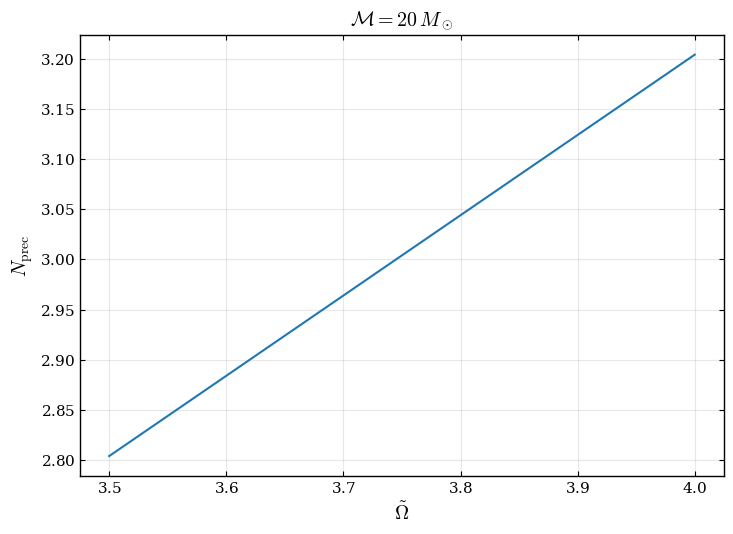

In [4]:
omega_arr = np.linspace(3.5, 4, 51)  # [dimensionless]
mcz = 20  # [M_sun]
nprec_arr = number_of_prec_cycles(mcz, omega_arr)  # [dimensionless]

plt.figure(figsize=(7.5, 5.5))
plt.plot(omega_arr, nprec_arr)
plt.xlabel(r"$\tilde{\Omega}$")
plt.ylabel(r"$N_\mathrm{prec}$")
plt.title(rf"$\mathcal{{M}}={mcz:.0f}\,M_\odot$")
plt.grid(True, alpha=0.3)
plt.tight_layout()